In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 2: Load and preprocess dataset
df = pd.read_csv("labelled_merged_dataset.csv")

title_counts = df['Title'].value_counts()
df['IsChain'] = df['Title'].apply(lambda x: 1 if title_counts[x] > 1 else 0)

def parse_categories(x):
    try:
        return len(ast.literal_eval(x)) if pd.notnull(x) else 0
    except:
        return 0
df['tag_count'] = df['Categories'].apply(parse_categories)
df['RatingBinary'] = df['Rating'].map({'Good': 1, 'Bad': 0})

df.head()

,Title,Category,Rating,Address,Categories,ZCTA,NAME,Median_Income,Population,Males_20yrs_age,...,Males_60yrs_age,Females_20yrs_age,Females_30yrs_age,Females_60yrs_age,Asian,American,Hispanic_or_Latino,IsChain,tag_count,RatingBinary
0,Dairy Queen Grill & Chill,Fast food restaurant,Bad,"Dairy Queen Grill & Chill, 3143 US-280, Alexan...","['Fast food restaurant', 'Ice cream shop']",35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,2,0
1,Jake's Restaurant,American restaurant,Good,"Jake's Restaurant, 16 Broad St, Alexander City...",['American restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,1,1
2,Carib Kitchen,Caribbean restaurant,Good,"Carib Kitchen, 68 Broad St, Alexander City, AL...",['Caribbean restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,0,1,1
3,Cazadores Mexican Restaurant,Mexican restaurant,Good,"Cazadores Mexican Restaurant, 910 Cherokee Rd,...",['Mexican restaurant'],35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,1,1
4,La Posada Mexican Grill,Mexican restaurant,Bad,"La Posada Mexican Grill, 3714 US-280, Alexande...","['Mexican restaurant', 'Latin American restaur...",35010,ZCTA5 35010,46730,20406,414,...,409,246,636,434,107,1864,899,1,2,0


In [2]:
from sklearn.preprocessing import StandardScaler
# Step 3: Define features and label
features = ['Median_Income', 'Population', 'American', 'Asian', 'Hispanic_or_Latino', 'IsChain', 'tag_count']
X = df[features]
y = df['RatingBinary']

# Step 4: Standardize the features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-Test Split (stratified to preserve label ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

# Display samples
print("Cleaned Data Sample: \n")
print(df[features + ['RatingBinary']].head())

train_sample = pd.DataFrame(X_train, columns=features)
test_sample = pd.DataFrame(X_test, columns=features)

print("\n Training Set Sample (80%): \n")
train_sample['RatingBinary'] = y_train.values
print(train_sample.head())

print("\n Testing Set Sample (20%): \n")
test_sample['RatingBinary'] = y_test.values
print(test_sample.head())

Cleaned Data Sample: 

   Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
0          46730       20406      1864    107                 899        1          2             0
1          46730       20406      1864    107                 899        1          1             1
2          46730       20406      1864    107                 899        0          1             1
3          46730       20406      1864    107                 899        1          1             1
4          46730       20406      1864    107                 899        1          2             0

 Training Set Sample (80%): 

   Median_Income  Population  American     Asian  Hispanic_or_Latino   IsChain  tag_count  RatingBinary
0       0.180318   -1.413102 -0.583995 -0.442815           -0.559532 -0.724457  -0.885783             1
1       0.124473    2.562481 -0.156910  0.896870            1.990101  1.380344   0.017960             0
2      -0.570301   -1.496953 -0.89

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)


Random Forest Test Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63     13795
           1       0.62      0.66      0.64     13352

    accuracy                           0.63     27147
   macro avg       0.64      0.63      0.63     27147
weighted avg       0.64      0.63      0.63     27147



<Figure size 600x400 with 0 Axes>

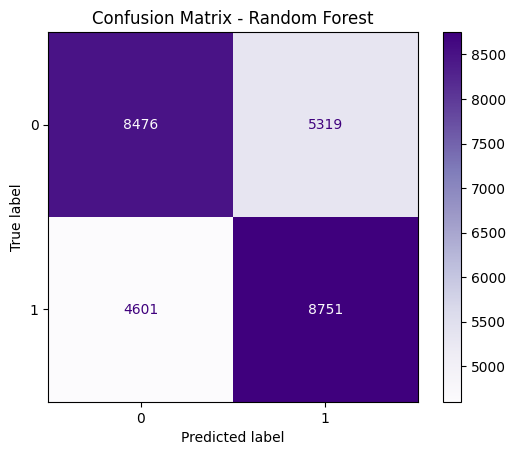

In [6]:
# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {acc_rf:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Pretty Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
plt.figure(figsize=(6, 4))
disp.plot(cmap="Purples", values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()



Feature Importances:
              Feature  Importance
6           tag_count    0.224087
5             IsChain    0.169904
0       Median_Income    0.121987
4  Hispanic_or_Latino    0.121484
1          Population    0.121321
3               Asian    0.120773
2            American    0.120445


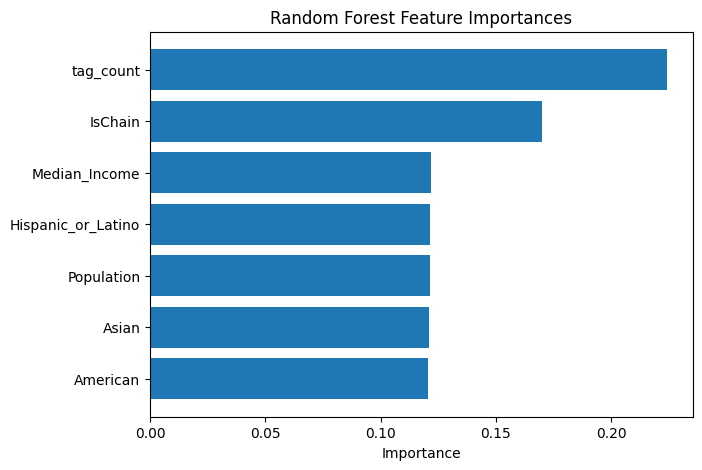

In [7]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = features

# Convert to DataFrame for nice sorting
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feat_importance_df)

# Plotting Feature Importances
plt.figure(figsize=(7, 5))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(False)
plt.show()
